In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [26]:
data = pd.read_csv('F:/Python/Diabetes Prediction/Prediction.csv')

In [27]:
data

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,skin,diabetes,Unnamed: 10
0,6,148,72,35,0,33.6,0.627,50,1.3790,True,NaN
1,1,85,66,29,0,26.6,0.351,31,1.1426,False,NaN
2,8,183,64,0,0,23.3,0.672,32,0.0000,True,NaN
3,1,89,66,23,94,28.1,0.167,21,0.9062,False,NaN
4,0,137,40,35,168,43.1,2.288,33,1.3790,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,1.8912,False,NaN
764,2,122,70,27,0,36.8,0.340,27,1.0638,False,NaN
765,5,121,72,23,112,26.2,0.245,30,0.9062,False,NaN
766,1,126,60,0,0,30.1,0.349,47,0.0000,True,NaN


In [11]:
data.head(10)

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,skin,diabetes,Unnamed: 10
0,6,148,72,35,0,33.6,0.627,50,1.3790,True,NaN
1,1,85,66,29,0,26.6,0.351,31,1.1426,False,NaN
2,8,183,64,0,0,23.3,0.672,32,0.0000,True,NaN
3,1,89,66,23,94,28.1,0.167,21,0.9062,False,NaN
4,0,137,40,35,168,43.1,2.288,33,1.3790,True,NaN
5,5,116,74,0,0,25.6,0.201,30,0.0000,False,NaN
6,3,78,50,32,88,31.0,0.248,26,1.2608,True,NaN
7,10,115,0,0,0,35.3,0.134,29,0.0000,False,NaN
8,2,197,70,45,543,30.5,0.158,53,1.7730,True,NaN
9,8,125,96,0,0,0.0,0.232,54,0.0000,True,NaN


In [12]:
data.tail(10)

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,skin,diabetes,Unnamed: 10
758,1,106,76,0,0,37.5,0.197,26,0.0000,False,NaN
759,6,190,92,0,0,35.5,0.278,66,0.0000,True,NaN
760,2,88,58,26,16,28.4,0.766,22,1.0244,False,NaN
761,9,170,74,31,0,44.0,0.403,43,1.2214,True,NaN
762,9,89,62,0,0,22.5,0.142,33,0.0000,False,NaN
763,10,101,76,48,180,32.9,0.171,63,1.8912,False,NaN
764,2,122,70,27,0,36.8,0.340,27,1.0638,False,NaN
765,5,121,72,23,112,26.2,0.245,30,0.9062,False,NaN
766,1,126,60,0,0,30.1,0.349,47,0.0000,True,NaN
767,1,93,70,31,0,30.4,0.315,23,1.2214,False,NaN


In [13]:
data.isnull().sum()

num_preg          0
glucose_conc      0
diastolic_bp      0
thickness         0
insulin           0
bmi               0
diab_pred         0
age               0
skin              0
diabetes          0
Unnamed: 10     768
dtype: int64

In [14]:
import seaborn as sns

In [15]:
corrmat = data.corr()

In [16]:
corrmat

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,skin,diabetes,Unnamed: 10
num_preg,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,-0.081672,0.221898,NaN
glucose_conc,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.057328,0.466581,NaN
diastolic_bp,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.207371,0.065068,NaN
thickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,1.000000,0.074752,NaN
insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.436783,0.130548,NaN
bmi,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.392573,0.292695,NaN
diab_pred,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.183928,0.173844,NaN
age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,-0.113970,0.238356,NaN
skin,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,1.000000,0.074752,NaN
diabetes,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,0.074752,1.000000,NaN


In [17]:
top_corr_features = corrmat.index

In [18]:
top_corr_features

Index(['num_preg', 'glucose_conc', 'diastolic_bp', 'thickness', 'insulin',
       'bmi', 'diab_pred', 'age', 'skin', 'diabetes', 'Unnamed: 10'],
      dtype='object')

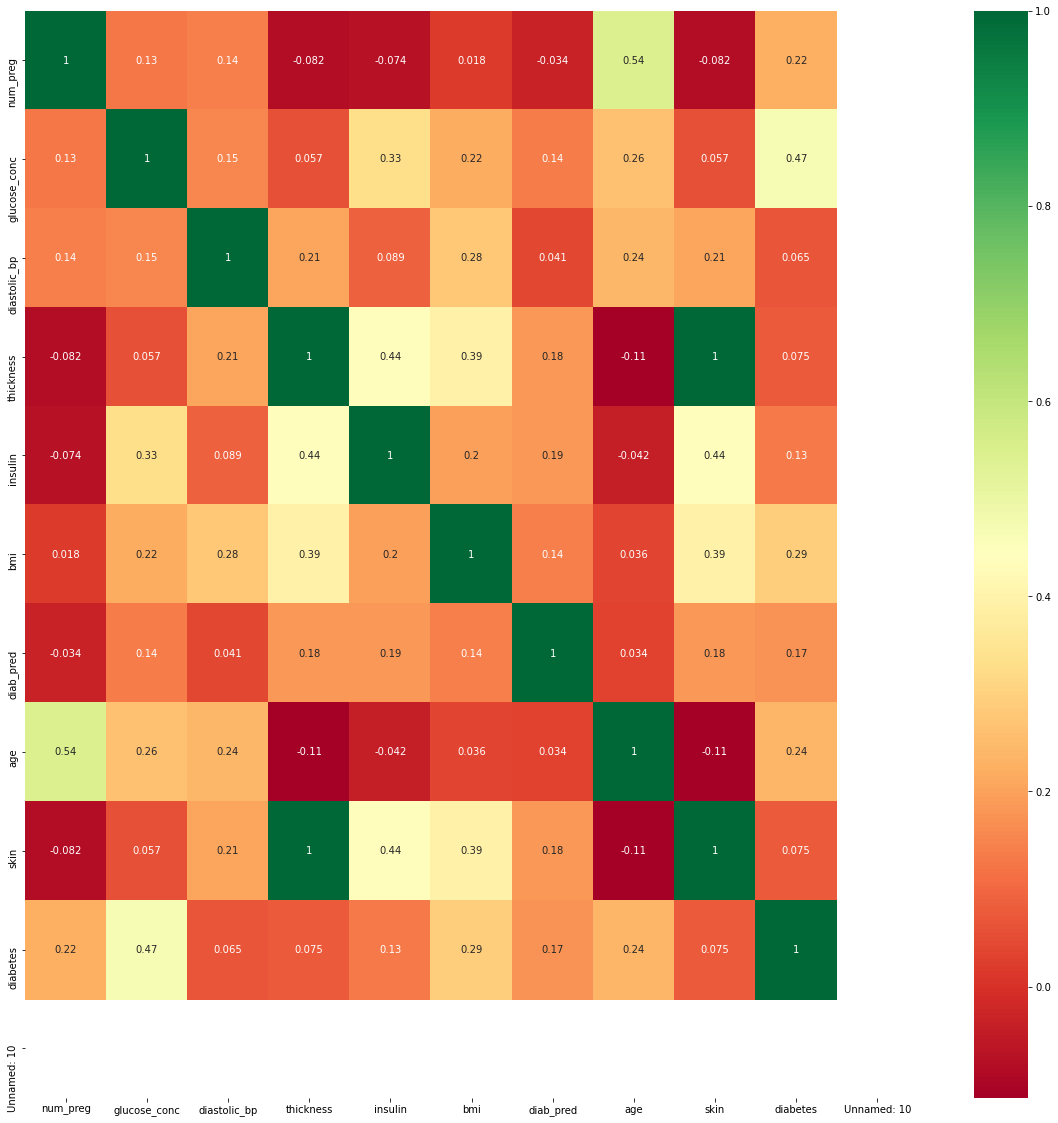

In [23]:
plt.figure(figsize = (20,20))
sns.heatmap(data[top_corr_features].corr(), annot=True, cmap ="RdYlGn")

# Changing the diabeties column data from boolean to number

In [24]:
diabetes_map = {True: 1, False: 0}
data['diabetes'] = data['diabetes'].map(diabetes_map)

In [25]:
data.head(10)

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,skin,diabetes,Unnamed: 10
0,6,148,72,35,0,33.6,0.627,50,1.3790,1,NaN
1,1,85,66,29,0,26.6,0.351,31,1.1426,0,NaN
2,8,183,64,0,0,23.3,0.672,32,0.0000,1,NaN
3,1,89,66,23,94,28.1,0.167,21,0.9062,0,NaN
4,0,137,40,35,168,43.1,2.288,33,1.3790,1,NaN
5,5,116,74,0,0,25.6,0.201,30,0.0000,0,NaN
6,3,78,50,32,88,31.0,0.248,26,1.2608,1,NaN
7,10,115,0,0,0,35.3,0.134,29,0.0000,0,NaN
8,2,197,70,45,543,30.5,0.158,53,1.7730,1,NaN
9,8,125,96,0,0,0.0,0.232,54,0.0000,1,NaN


In [28]:
diabetes_true_count = len(data.loc[data['diabetes'] == True])
diabetes_false_count = len(data.loc[data['diabetes'] == False])

In [29]:
diabetes_true_count, diabetes_false_count

(268, 500)

In [30]:
data.columns

Index(['num_preg', 'glucose_conc', 'diastolic_bp', 'thickness', 'insulin',
       'bmi', 'diab_pred', 'age', 'skin', 'diabetes', 'Unnamed: 10'],
      dtype='object')

In [31]:
#train test split

from sklearn.model_selection import train_test_split

feature_columns = ['num_preg', 'glucose_conc', 'diastolic_bp', 'thickness', 'insulin', 'bmi', 'diab_pred', 'age', 'skin']
predicted_class = ['diabetes']

In [32]:
x = data[feature_columns].values
y = data[predicted_class].values

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=.30, random_state=10)

In [33]:
print("total number of rows : {0}".format(len(data)))
print("number of rows missing glucose_conc: {0}".format(len(data.loc[data['glucose_conc'] == 0])))
print("number of rows missing diastolic_bp: {0}".format(len(data.loc[data['diastolic_bp'] == 0])))
print("number of rows missing thickness: {0}".format(len(data.loc[data['thickness'] == 0])))
print("number of rows missing insulin: {0}".format(len(data.loc[data['insulin'] == 0])))
print("number of rows missing bmi: {0}".format(len(data.loc[data['bmi'] == 0])))
print("number of rows missing diab_pred: {0}".format(len(data.loc[data['diab_pred'] == 0])))
print("number of rows missing age: {0}".format(len(data.loc[data['age'] == 0])))
print("number of rows missing skin: {0}".format(len(data.loc[data['skin'] == 0])))

total number of rows : 768
number of rows missing glucose_conc: 5
number of rows missing diastolic_bp: 35
number of rows missing thickness: 227
number of rows missing insulin: 374
number of rows missing bmi: 11
number of rows missing diab_pred: 0
number of rows missing age: 0
number of rows missing skin: 227


In [37]:
from sklearn.impute import SimpleImputer

fill_values = SimpleImputer(missing_values=0, strategy="mean")

x_train = fill_values.fit_transform(x_train)
x_test = fill_values.fit_transform(x_test)

In [38]:
x_train

array([[2.0000e+00, 8.9000e+01, 9.0000e+01, ..., 2.9200e-01, 4.2000e+01,
        1.1820e+00],
       [4.0000e+00, 1.4600e+02, 8.5000e+01, ..., 1.8900e-01, 2.7000e+01,
        1.0638e+00],
       [1.0000e+01, 1.1100e+02, 7.0000e+01, ..., 1.4100e-01, 4.0000e+01,
        1.0638e+00],
       ...,
       [3.0000e+00, 1.1600e+02, 7.4000e+01, ..., 1.0700e-01, 2.4000e+01,
        5.9100e-01],
       [1.0000e+00, 8.8000e+01, 3.0000e+01, ..., 4.9600e-01, 2.6000e+01,
        1.6548e+00],
       [5.0000e+00, 9.6000e+01, 7.4000e+01, ..., 9.9700e-01, 4.3000e+01,
        7.0920e-01]])

In [39]:
x_test

array([[  4.        , 154.        ,  72.        , ...,   0.338     ,
         37.        ,   1.1426    ],
       [  2.        , 112.        ,  86.        , ...,   0.246     ,
         28.        ,   1.6548    ],
       [  1.        , 135.        ,  54.        , ...,   0.687     ,
         62.        ,   1.17406711],
       ...,
       [  3.        , 150.        ,  76.        , ...,   0.207     ,
         37.        ,   1.17406711],
       [  3.        , 130.        ,  64.        , ...,   0.314     ,
         22.        ,   1.17406711],
       [  4.81578947, 108.        ,  68.        , ...,   0.787     ,
         32.        ,   0.788     ]])

In [40]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(random_state= 10)

random_forest_model.fit(x_train, y_train.ravel())

RandomForestClassifier(random_state=10)

In [41]:
predict_train_data = random_forest_model.predict(x_test)

In [43]:
from sklearn import metrics

print("Acuracy = {0:3f}".format(metrics.accuracy_score(y_test,predict_train_data)))

Acuracy = 0.753247
